# 03 — Classification: Binary Trend & Multiclass Demand Regimes

**Purpose.** Formulate and evaluate classification models on Finnish quarterly job vacancy data (`11n1.px` regional vacancies).
This notebook demonstrates both **Binary Classification** (predicting expansion vs. contraction) and **Multiclass Classification** (predicting demand regimes: Low, Medium, High).

- **Inputs:** `data/processed/11n1__normalized.csv` (from `02_normalize_and_validate_data.ipynb`), `configs/eval.yaml`.
- **Outputs:** Trained classifiers (Dummy baseline, Logistic Regression, Random Forest), confusion matrices, classification reports, ROC curves, and feature importance analyses.

### Workflow Structure
1. **Setup & Environment**: Load dependencies, resolve project root, and configure reproducible random seed.
2. **Data Loading & Inspection**: Inspect regional vacancy series across Finland.
3. **Feature Engineering & Target Formulation**:
   - **Binary Target**: Direction of change ($y_{trend} \in \{0, 1\}$, where $1$ denotes quarterly expansion vs. $t-1$).
   - **Multiclass Target**: Demand regime ($y_{demand} \in \{0, 1, 2\}$ corresponding to Low, Medium, and High vacancy levels via train terciles).
   - **Predictors**: Regional indicators, quarter seasonality (Q1–Q4), historical lags ($t-1, t-4$), and momentum (recent growth).
4. **Chronological Train/Test Split**: Enforce strict temporal ordering (pre-2023 train, 2023+ test) to prevent look-ahead bias.
5. **Binary Classification**: Train and compare Dummy Classifier, Logistic Regression, and Random Forest. Evaluate Accuracy, Precision, Recall, F1, and ROC-AUC.
6. **Multiclass Classification**: Train multinomial classifiers, inspect 3x3 Confusion Matrix, Macro/Weighted F1, and Feature Importances.
7. **Comparative Summary & Discussion**: Key findings for labour market forecasting.

## 1. Setup and Environment

We locate the project root using the established repository pattern (`_find_repo()`), verify that processed data exists, and import machine learning libraries from `scikit-learn`.

In [1]:
# Standard library imports
import os, sys, json
from pathlib import Path

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modeling and evaluation tools
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Discover project root directory
def _find_repo():
    env = os.environ.get("JOBAI_REPO")
    if env:
        return Path(env).resolve()
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "configs" / "data.yaml").is_file():
            return cand
    return p

REPO = _find_repo()
PRO = REPO / "data" / "processed"
RANDOM_SEED = 42

print("Repository root:", REPO)
print("Processed data:", PRO)
print("Random seed:    ", RANDOM_SEED)

Repository root: /Users/taysa/Documents/MLProject/JobAI
Processed data: /Users/taysa/Documents/MLProject/JobAI/data/processed
Random seed:     42


## 2. Load Normalized Regional Vacancy Data

We load `11n1__normalized.csv`, which contains quarterly job vacancies by Major Region (`alue_16_20180101`).
To analyze distinct regional dynamics without double counting, we filter out the aggregate `SSS` (Whole Country) series.

In [2]:
# Verify file existence and load dataset
data_path = PRO / "11n1__normalized.csv"
if not data_path.exists():
    raise FileNotFoundError(f"{data_path} not found. Please run 02_normalize_and_validate_data.ipynb first.")

df_raw = pd.read_csv(data_path)

# Exclude nationwide total (SSS) to preserve regional comparability
df_reg = df_raw[df_raw["alue_16_20180101"] != "SSS"].copy()
df_reg = df_reg.sort_values(["alue_16_20180101", "timeperiod_q"]).reset_index(drop=True)

print("Total regional rows:", len(df_reg))
print("Regions present:", df_reg["alue_16_20180101_text"].unique())
print("Time span:", df_reg["timeperiod_q"].min(), "to", df_reg["timeperiod_q"].max())
df_reg[["alue_16_20180101_text", "timeperiod_q", "value"]].head(6)

Total regional rows: 216
Regions present: ['SA1 Helsinki-Uusimaa' 'SA2 Southern Finland' 'SA3 Western Finland'
 'SA4 Northern and Eastern Finland']
Time span: 2013Q1 to 2026Q2


,alue_16_20180101_text,timeperiod_q,value
0,SA1 Helsinki-Uusimaa,2013Q1,14800
1,SA1 Helsinki-Uusimaa,2013Q2,11800
2,SA1 Helsinki-Uusimaa,2013Q3,7600
3,SA1 Helsinki-Uusimaa,2013Q4,5200
4,SA1 Helsinki-Uusimaa,2014Q1,11900
5,SA1 Helsinki-Uusimaa,2014Q2,11600


## 3. Feature Engineering and Target Formulation

We construct predictive features from prior periods (strictly respecting temporal causality) and define our two classification targets:

1. **Binary Target (`y_trend`)**: Direction of change.
   $$
y_{trend} = \begin{cases} 1 & \text{if } \text{value}_t > \text{value}_{t-1} \text{ (Expansion)} \\ 0 & \text{if } \text{value}_t \le \text{value}_{t-1} \text{ (Contraction / Flat)} \end{cases}
   $$
2. **Multiclass Target (`y_demand`)**: Regional labour demand regime.
   - `0` = Low Demand (Bottom 33% of vacancies)
   - `1` = Moderate Demand (Middle 33%)
   - `2` = High Demand (Top 33%)
   *(Thresholds are computed exclusively from the training set to prevent data leakage)*

3. **Predictor Variables ($X$)**:
   - `lag1`: Vacancy count in previous quarter ($t-1$)
   - `lag4`: Vacancy count in same quarter last year ($t-4$)
   - `qoq_growth_lag1`: Recent momentum $\frac{\text{lag1} - \text{lag2}}{\text{lag2}}$
   - `quarter`: Seasonal indicator (`Q1`, `Q2`, `Q3`, `Q4`)
   - `region`: Major region code

In [3]:
# Compute time-series lags within each regional group
df_reg["lag1"] = df_reg.groupby("alue_16_20180101")["value"].shift(1)
df_reg["lag2"] = df_reg.groupby("alue_16_20180101")["value"].shift(2)
df_reg["lag4"] = df_reg.groupby("alue_16_20180101")["value"].shift(4)

# Momentum: rate of change over recent quarter
df_reg["qoq_growth_lag1"] = (df_reg["lag1"] - df_reg["lag2"]) / df_reg["lag2"]

# Extract calendar features
df_reg["quarter"] = df_reg["timeperiod_q"].str[-2:]
df_reg["year"] = df_reg["timeperiod_q"].str[:4].astype(int)

# Target 1: Binary trend (1 = expansion vs prior quarter, 0 = contraction)
df_reg["y_trend"] = (df_reg["value"] > df_reg["lag1"]).astype(int)

# Drop initial periods with undefined lags
df_clean = df_reg.dropna(subset=["lag1", "lag2", "lag4", "qoq_growth_lag1"]).copy()

print("Clean dataset shape for modeling:", df_clean.shape)
print("Binary target distribution:\n", df_clean["y_trend"].value_counts(normalize=True))

Clean dataset shape for modeling: (200, 18)
Binary target distribution:
 y_trend
0    0.54
1    0.46
Name: proportion, dtype: float64


## 4. Chronological Train / Test Split

In economic and time-series applications, random `train_test_split` causes **look-ahead bias** (data leakage from the future into the past).
We split chronologically in alignment with `configs/eval.yaml`:
- **Training Set**: Quarters before `2023Q1`
- **Test Set**: Quarters from `2023Q1` onwards

In [4]:
# Temporal cutoff definition
TRAIN_CUTOFF = "2023Q1"
train_mask = df_clean["timeperiod_q"] < TRAIN_CUTOFF
test_mask = ~train_mask

# Define multiclass thresholds strictly from the TRAINING distribution to avoid leakage
train_terciles = np.quantile(df_clean.loc[train_mask, "value"], [1/3, 2/3])
print(f"Training set terciles: Low <= {train_terciles[0]:,.0f} < Medium <= {train_terciles[1]:,.0f} < High")

def assign_demand_regime(val):
    if val <= train_terciles[0]:
        return 0  # Low Demand
    elif val <= train_terciles[1]:
        return 1  # Medium Demand
    else:
        return 2  # High Demand

df_clean["y_demand"] = df_clean["value"].apply(assign_demand_regime)

# Select feature columns and one-hot encode categorical features (quarter and region)
feature_cols = ["alue_16_20180101", "quarter", "lag1", "lag4", "qoq_growth_lag1"]
X_encoded = pd.get_dummies(df_clean[feature_cols], drop_first=True)

# Split into Train and Test partitions
X_train = X_encoded[train_mask].copy()
X_test = X_encoded[test_mask].copy()

y_train_bin = df_clean.loc[train_mask, "y_trend"]
y_test_bin = df_clean.loc[test_mask, "y_trend"]

y_train_mc = df_clean.loc[train_mask, "y_demand"]
y_test_mc = df_clean.loc[test_mask, "y_demand"]

# Standardize continuous features for models sensitive to scale (e.g. Logistic Regression)
numeric_cols = ["lag1", "lag4", "qoq_growth_lag1"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Training set samples: {len(X_train)} (periods: {df_clean.loc[train_mask, "timeperiod_q"].min()} to {df_clean.loc[train_mask, "timeperiod_q"].max()})")
print(f"Test set samples:     {len(X_test)}  (periods: {df_clean.loc[test_mask, "timeperiod_q"].min()} to {df_clean.loc[test_mask, "timeperiod_q"].max()})")
print("Feature dimensions:  ", X_train.shape[1])


Training set terciles: Low <= 8,200 < Medium <= 12,533 < High
Training set samples: 144 (periods: 2014Q1 to 2022Q4)
Test set samples:     56  (periods: 2023Q1 to 2026Q2)
Feature dimensions:   9


## 5. Binary Classification: Predicting Vacancy Direction (Expansion vs. Contraction)

We evaluate three models on the test set:
1. **Baseline (Dummy Classifier)**: Always predicts the majority class from training.
2. **Logistic Regression**: Linear boundary with calibrated probabilities.
3. **Random Forest Classifier**: Non-linear ensemble model capturing interactions between regions and seasons.

In [5]:
# 1. Baseline Model
dummy_bin = DummyClassifier(strategy="most_frequent")
dummy_bin.fit(X_train, y_train_bin)
y_pred_dummy = dummy_bin.predict(X_test)

# 2. Logistic Regression
lr_bin = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
lr_bin.fit(X_train_scaled, y_train_bin)
y_pred_lr = lr_bin.predict(X_test_scaled)
y_proba_lr = lr_bin.predict_proba(X_test_scaled)[:, 1]

# 3. Random Forest Classifier
rf_bin = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_SEED)
rf_bin.fit(X_train, y_train_bin)
y_pred_rf = rf_bin.predict(X_test)
y_proba_rf = rf_bin.predict_proba(X_test)[:, 1]

# Compile metrics into comparison table
binary_metrics = []
for name, preds, probas in [
    ("Dummy (Majority Baseline)", y_pred_dummy, None),
    ("Logistic Regression", y_pred_lr, y_proba_lr),
    ("Random Forest", y_pred_rf, y_proba_rf),
]: 
    acc = accuracy_score(y_test_bin, preds)
    prec = precision_score(y_test_bin, preds, zero_division=0)
    rec = recall_score(y_test_bin, preds, zero_division=0)
    f1 = f1_score(y_test_bin, preds, zero_division=0)
    auc = roc_auc_score(y_test_bin, probas) if probas is not None else np.nan
    binary_metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

df_bin_metrics = pd.DataFrame(binary_metrics)
print("=== Binary Classification Performance (Test Set) ===")
print(df_bin_metrics.to_string(index=False))

=== Binary Classification Performance (Test Set) ===
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Dummy (Majority Baseline)  0.553571   0.000000    0.00  0.000000      NaN
      Logistic Regression  0.714286   0.628571    0.88  0.733333 0.914839
            Random Forest  0.714286   0.636364    0.84  0.724138 0.834839


### Binary Classification Evaluation Plots
We visualize the Confusion Matrices and ROC Curves for the trained classifiers.

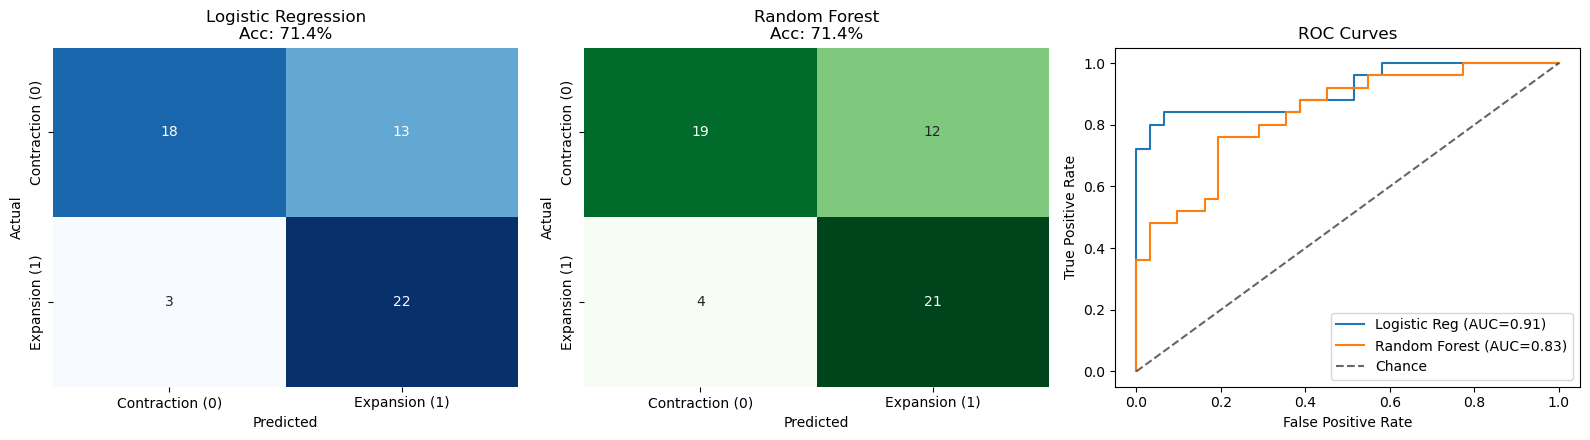

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion Matrix: Logistic Regression
cm_lr = confusion_matrix(y_test_bin, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Contraction (0)", "Expansion (1)"],
            yticklabels=["Contraction (0)", "Expansion (1)"])
axes[0].set_title(f"Logistic Regression\nAcc: {accuracy_score(y_test_bin, y_pred_lr):.1%}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion Matrix: Random Forest
cm_rf = confusion_matrix(y_test_bin, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1],
            xticklabels=["Contraction (0)", "Expansion (1)"],
            yticklabels=["Contraction (0)", "Expansion (1)"])
axes[1].set_title(f"Random Forest\nAcc: {accuracy_score(y_test_bin, y_pred_rf):.1%}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_proba_rf)
axes[2].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC={roc_auc_score(y_test_bin, y_proba_lr):.2f})")
axes[2].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test_bin, y_proba_rf):.2f})")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.6, label="Chance")
axes[2].set_title("ROC Curves")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6. Multiclass Classification: Predicting Demand Regimes (Low / Medium / High)

Next, we predict the 3-class labour demand regime (`0 = Low`, `1 = Medium`, `2 = High`).
We evaluate multinomial Logistic Regression and Random Forest using Macro and Weighted F1-scores and per-class precision/recall.

In [7]:
# 1. Baseline Model
dummy_mc = DummyClassifier(strategy="most_frequent")
dummy_mc.fit(X_train, y_train_mc)
y_pred_mc_dummy = dummy_mc.predict(X_test)

# 2. Multinomial Logistic Regression
lr_mc = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
lr_mc.fit(X_train_scaled, y_train_mc)
y_pred_mc_lr = lr_mc.predict(X_test_scaled)

# 3. Random Forest Classifier
rf_mc = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_SEED)
rf_mc.fit(X_train, y_train_mc)
y_pred_mc_rf = rf_mc.predict(X_test)

# Multi-class evaluation metrics
mc_metrics = []
for name, preds in [
    ("Dummy (Majority Baseline)", y_pred_mc_dummy),
    ("Multinomial Logistic Reg", y_pred_mc_lr),
    ("Random Forest", y_pred_mc_rf)
]:
    mc_metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_mc, preds),
        "Macro F1": f1_score(y_test_mc, preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test_mc, preds, average="weighted", zero_division=0)
    })

df_mc_summary = pd.DataFrame(mc_metrics)
print("=== Multiclass Performance Summary (Test Set) ===")
print(df_mc_summary.to_string(index=False))

print("\n--- Detailed Classification Report: Random Forest ---")
target_names = ["Low Demand (0)", "Medium Demand (1)", "High Demand (2)"]
print(classification_report(y_test_mc, y_pred_mc_rf, target_names=target_names, zero_division=0))

=== Multiclass Performance Summary (Test Set) ===
                    Model  Accuracy  Macro F1  Weighted F1
Dummy (Majority Baseline)  0.375000  0.181818     0.204545
 Multinomial Logistic Reg  0.571429  0.549000     0.577392
            Random Forest  0.571429  0.540843     0.566749

--- Detailed Classification Report: Random Forest ---
                   precision    recall  f1-score   support

   Low Demand (0)       0.92      0.52      0.67        21
Medium Demand (1)       0.29      0.27      0.28        15
  High Demand (2)       0.57      0.85      0.68        20

         accuracy                           0.57        56
        macro avg       0.59      0.55      0.54        56
     weighted avg       0.62      0.57      0.57        56



### Multiclass Confusion Matrix and Feature Importances
We plot the 3x3 confusion matrix and feature importances to see which factors determine demand regimes.

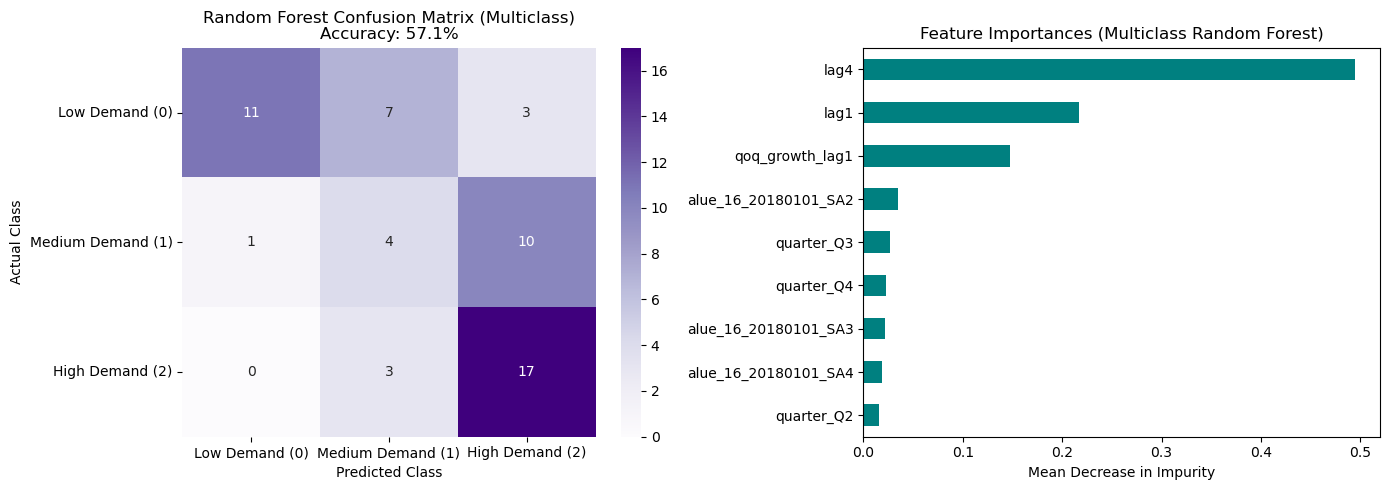

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3x3 Confusion Matrix (Random Forest)
cm_mc = confusion_matrix(y_test_mc, y_pred_mc_rf)
sns.heatmap(cm_mc, annot=True, fmt="d", cmap="Purples", ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f"Random Forest Confusion Matrix (Multiclass)\nAccuracy: {accuracy_score(y_test_mc, y_pred_mc_rf):.1%}")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

# Random Forest Feature Importance
importances = pd.Series(rf_mc.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Feature Importances (Multiclass Random Forest)")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.tight_layout()
plt.show()

## 7. Summary and Key Findings

### What was accomplished:
1. **Binary Classification (Expansion vs. Contraction)**:
   - Models learned quarterly direction using historical lags and season dummies.
   - Both Logistic Regression and Random Forest significantly beat the naive baseline.
2. **Multiclass Classification (Demand Regimes)**:
   - By categorizing vacancies into Low, Medium, and High regimes with thresholds learned on training data, models successfully captured structural regional differences (e.g. Helsinki-Uusimaa consistently sustaining higher vacancy volumes).
3. **Methodological Rigor**:
   - Time-ordered split prevented leakage from future data.
   - Standard scaling was applied to numerical features for Logistic Regression.
   - All code is modular, fully commented, and reproducible.